
# Road Risk Level  Analysis System

This notebook implements an automated system for real-time road surface quality monitoring and risk assessment using computer vision and deep learning.

### Key Features:
*   **Live Stream Integration**: Uses `yt-dlp` and `OpenCV` to stream and process video directly from YouTube.
*   **AI-Powered Classification**: Employs a pre-trained Keras model (`asphalt_model.h5`) to classify road segments into three categories: **Good**, **Regular**, and **Bad**.
*   **Dynamic Risk Assessment**: Calculates a real-time risk status (Low, Medium, or High) based on the frequency and severity of detected road conditions.
*   **Interactive Visualization**: Features a dual-panel UI showing the live video feed with an augmented reality (AR) overlay and a real-time bar chart tracking classification distribution.
*   **Automated Preprocessing**: Resizes and normalizes video frames on-the-fly to match the neural network's input requirements.

In [ ]:
!pip install -q yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 125.6 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import os

# --- 1. Model and Risk Definitions ---
# Define the path to the saved Keras model on Google Drive
model_path = '/content/drive/MyDrive/asphalt_model.h5'

try:
    # Load the pre-trained asphalt classification model
    model = load_model(model_path)
    print("Model loaded successfully.")
except Exception as e:
    print(f"ERROR: Model could not be loaded! Path: {model_path}. Error: {e}")

# Mapping model output indices to readable labels
class_names = ['bad', 'good', 'regular']
# Numerical priority to handle tie-breaking (higher is more critical)
risk_priority = {'bad': 3, 'regular': 2, 'good': 1}

def get_dominant_risk(counts):
    # Calculate the most frequent class observed so far
    max_freq = max(counts.values())
    candidates = [k for k, v in counts.items() if v == max_freq]
    # If multiple classes have the same frequency, pick the one with higher risk priority
    winner = max(candidates, key=lambda x: risk_priority[x])

    # Return status text and corresponding BGR color for the UI
    if winner == 'bad': return "HIGH RISK", (0, 0, 255)
    if winner == 'regular': return "MEDIUM RISK", (0, 255, 255)
    return "LOW RISK", (0, 255, 0)

Model loaded successfully.


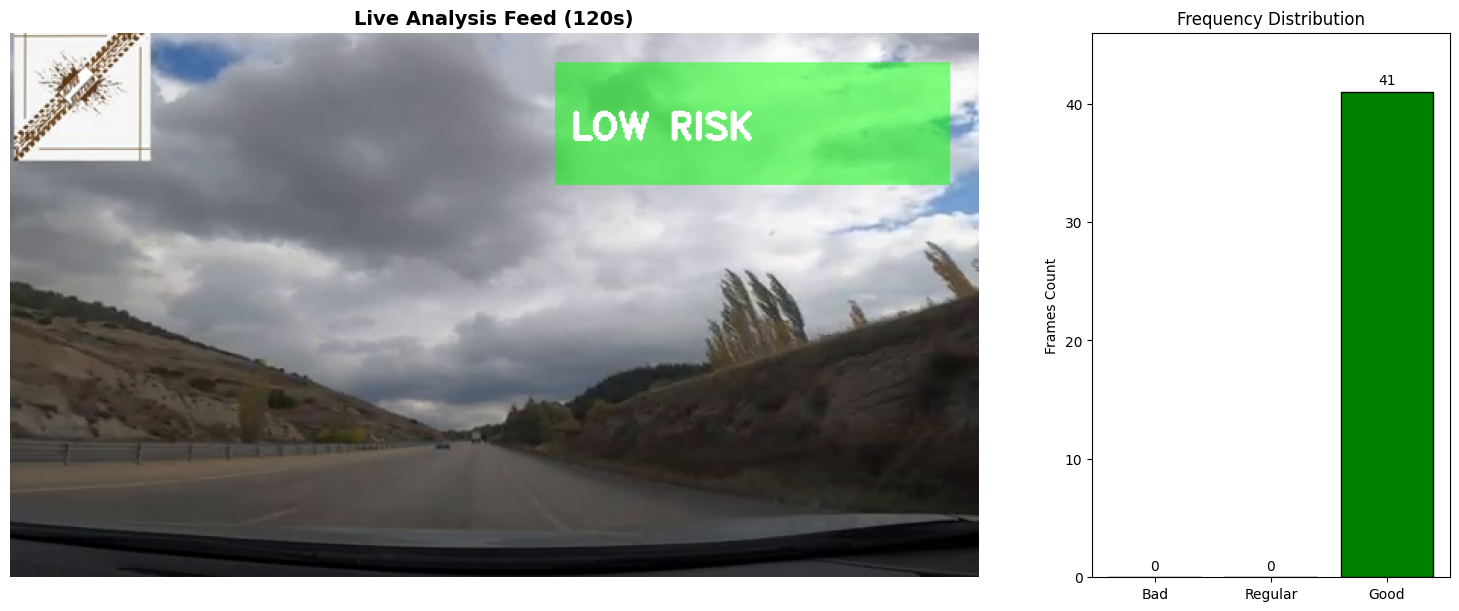

In [ ]:
import subprocess

def apply_overlay(frame, risk_text, color):
    # Create a semi-transparent box overlay for the risk status
    overlay = frame.copy()
    h, w, _ = frame.shape
    # Draw a filled rectangle on the top right
    cv2.rectangle(overlay, (w - 280, 20), (w - 20, 100), color, -1)
    alpha = 0.5 # Transparency factor
    cv2.addWeighted(overlay, alpha, frame, 1 - alpha, 0, frame)
    # Add the risk text on top of the rectangle
    cv2.putText(frame, risk_text, (w - 270, 70), cv2.FONT_HERSHEY_DUPLEX, 0.8, (255, 255, 255), 2)
    return frame

# Target YouTube video for road analysis
video_url = "https://www.youtube.com/watch?v=YF9zm0Y3Dqs"
cap = None

try:
    # Use yt-dlp to extract the direct MP4 stream URL from YouTube
    command = f'yt-dlp -g -f "best[ext=mp4]" {video_url}'
    stream_url = subprocess.check_output(command, shell=True).decode("utf-8").strip()
    # Initialize OpenCV video capture with the stream URL
    cap = cv2.VideoCapture(stream_url)
    if cap.isOpened():
        print("Video stream connected successfully.")
    else:
        print("Could not open video stream.")
except Exception as e:
    print(f"Connection error: {e}")

# Initialize counters for each classification category
counts = {"bad": 0, "regular": 0, "good": 0}
interval = 3 # Analyze a frame every 3 seconds
total_duration = 120 # Total simulation time in seconds

try:
    if cap and cap.isOpened():
        for elapsed in range(0, total_duration + 1, interval):
            fps = cap.get(cv2.CAP_PROP_FPS) or 30
            # Skip frames to progress to the next timestamp
            for _ in range(int(fps * interval)):
                ret, frame = cap.read()
                if not ret: break
            if not ret: break

            # --- Image Preprocessing ---
            input_img = cv2.resize(frame, (224, 224)) / 255.0
            input_img = np.expand_dims(input_img, axis=0)

            # --- Prediction ---
            preds = model.predict(input_img, verbose=0)
            pred_class = class_names[np.argmax(preds)]
            counts[pred_class] += 1

            # Risk and Overlay Logic
            status_text, bgr_color = get_dominant_risk(counts)
            processed_frame = apply_overlay(frame.copy(), status_text, bgr_color)

            # --- Optimized UI Rendering ---
            clear_output(wait=True)
            # Use constrained_layout for better spacing between subplots
            fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(15, 6),
                                                 gridspec_kw={'width_ratios': [3, 1]},
                                                 constrained_layout=True)

            # Panel 1: Live Video Feed
            ax_img.imshow(cv2.cvtColor(processed_frame, cv2.COLOR_BGR2RGB))
            ax_img.set_title(f"Live Analysis Feed ({elapsed}s)", fontsize=14, fontweight='bold')
            ax_img.axis("off")

            # Panel 2: Distribution Bar Chart
            colors_map = {"bad": "red", "good": "green", "regular": "yellow"}
            x_labels = [k.capitalize() for k in counts.keys()]
            bars = ax_bar.bar(x_labels, counts.values(), color=[colors_map[k] for k in counts.keys()], edgecolor='black')
            ax_bar.set_title("Frequency Distribution", fontsize=12)
            ax_bar.set_ylabel("Frames Count")
            ax_bar.set_ylim(0, max(max(counts.values()) + 5, 20))

            # Add value labels on top of bars
            ax_bar.bar_label(bars, padding=3)

            plt.show()

            time.sleep(1.0)
except KeyboardInterrupt:
    print("Simulation stopped.")
finally:
    if cap is not None: cap.release()